# 00 — Detection efficiency and observed blips

The two measured products in `data/`, following the recipe in
`data/analyse_transients_data.ipynb`:

1. **Efficiency curves** — the analytic per-segment detection efficiency
   `efficiency_{n}_df3` (mode $n$, the calibrated $\chi^2_3$ hypothesis),
   averaged over the selected segments.
2. **Blips** — the `upcrossings_{n}` (contiguous runs of transient statistic
   $q>100$). Each blip's kick amplitude `transient_dv_hat` is turned into an
   imparted momentum in eV/$c$; blips above the **0.1 TeV** selection become
   impulse candidates in the per-mode `data_mode{n}.txt` analysis inputs.

Natural-unit momentum: $p_{[\rm eV/}c] = p_{\rm SI}\,(c/e)$ (SI kg m s$^{-1}$ $\to$ eV/$c$; momentum, not energy).

These three products — the per-mode efficiency $\varepsilon(q)$, the candidate
lists `data_mode{n}.txt`, and the live-time below — are the inputs to the limit
notebooks: [`01_limit_contour.ipynb`](01_limit_contour.ipynb) (one mode),
[`04_mode_comparison.ipynb`](04_mode_comparison.ipynb) (all three overlaid), and
[`05_composite.ipynb`](05_composite.ipynb) (composite, no atmosphere).

In [1]:
%matplotlib inline
from pathlib import Path
import os as _os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)

def save_figure(fig, name, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number prefix
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)

DATA = Path("..") / "data"
MODES = (1, 2, 3)
COLORS = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}  # one colour per mode
Q_STAT_THRESHOLD = 100   # transient statistic q defining an up-crossing (a blip)
Q_THRESH_TEV = 0.1       # momentum selection [TeV/c]: blips above this are candidates

# momentum unit conversions
C_LIGHT = 2.99792458e8       # m/s
E_CHARGE = 1.602176634e-19   # J/eV
EV_PER_SI = C_LIGHT / E_CHARGE          # p[eV/c] = p[kg m/s]*this (momentum, NU)
TEV_PER_SI = EV_PER_SI / 1e12           # p[TeV/c] = p[kg m/s]*this

df = pd.read_hdf(DATA / "fit_data_temp_lockin_transients_selected.hdf5")
npz = np.load(DATA / "selected_data_efficiency_curves.npz")  # momentum bins [SI]
DV_BINS = {n: npz[f"dv_bins_{n}"] for n in MODES}  # imparted momentum p [kg m/s]

# dv_bins_n = |dv|[volts] * K_n, with |dv| = logspace(-6,-3); recover K_n (SI/volt)
_dv_volts = np.logspace(-6, -3, 400)
K_VOLT_TO_SI = {n: float(np.median(DV_BINS[n] / _dv_volts)) for n in MODES}
print("volt->momentum K_n [kg m s^-1 / V]:",
      {n: f'{K_VOLT_TO_SI[n]:.3e}' for n in MODES})

volt->momentum K_n [kg m s^-1 / V]: {1: '1.691e-11', 2: '2.004e-11', 3: '1.371e-10'}


## Units & conversion: volts → momentum

Every observable here is a **momentum** (the momentum transfer $q$). In natural
units momentum is written in eV but is strictly **eV/$c$** — not energy.

The HDF5 gives each blip's kick amplitude `transient_dv_hat` in lock-in “volts”. The chain to momentum is

$$ |\hat{dv}|\;[\mathrm{V}] \;\xrightarrow{\times K_n}\; p\;[\mathrm{kg\,m\,s^{-1}}] \;\xrightarrow{\times\,c/e}\; p\;[\mathrm{eV}/c] \;\xrightarrow{\div 10^9}\; q\;[\mathrm{GeV}/c]. $$

- **$K_n$** (volts → SI momentum) $= \mathrm{conversion\_m\_V}_n \cdot f_n \cdot 2\pi \cdot m_{\rm sensor}$ (volts→displacement→velocity→momentum).
  We recover it empirically rather than hardcoding those constants: the npz
  `dv_bins_{n}` are exactly `np.logspace(-6, -3, 400) * K_n`, so
  `K_VOLT_TO_SI[n] = median(dv_bins_n / dv_volts)` — values ≈ 1.7e-11,
  2.0e-11, 1.4e-10 kg m s$^{-1}$/V.
- **$c/e = 1.8711\times10^{27}$** (`EV_PER_SI`) turns SI momentum into eV/$c$ —
  the single factor of $c$ ($1\,\mathrm{GeV}/c = 5.344\times10^{-19}$ kg m/s).
- The per-mode `data_mode{n}.txt` store $p$ in eV/$c$; the limit scan reads them
  and divides by $10^9$ to get $q$ in GeV/$c$.

## Efficiency curves

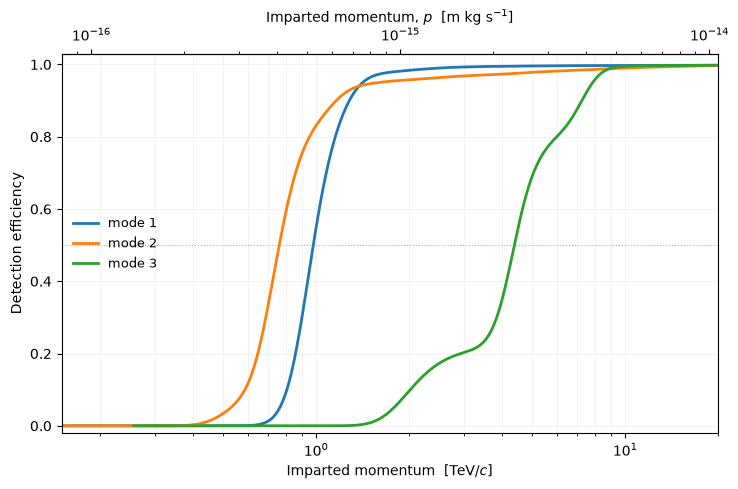

In [2]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for n in MODES:
    p_tev = DV_BINS[n] * TEV_PER_SI
    eff3 = np.vstack(df[f"efficiency_{n}_df3"].values).mean(axis=0)
    ax.plot(p_tev, eff3, color=COLORS[n], lw=2.0, label=f"mode {n}")
ax.set_xscale("log")
ax.set_xlim(0.15, 20)
ax.set_ylim(-0.02, 1.03)
ax.axhline(0.5, color="0.7", lw=0.8, ls=":", zorder=0)
ax.set_xlabel(r"Imparted momentum  [TeV/$c$]")
ax.set_ylabel("Detection efficiency")
ax.grid(True, which="both", alpha=0.15)
ax.legend(loc="center left", frameon=False, fontsize=9)
sec = ax.secondary_xaxis("top",
                         functions=(lambda t: t / TEV_PER_SI,
                                    lambda s: s * TEV_PER_SI))
sec.set_xlabel(r"Imparted momentum, $p$  [m kg s$^{-1}$]")
fig.tight_layout()
save_figure(fig, "00_efficiency_curves")
plt.show()

## Exposure

Live-time summed straight from the dataframe's per-segment `exposure_s`. This
total (≈ 469.7 h) is the exposure the limit scans assume — hard-coded once as
`config.T_EXPOSURE`, so the notebooks and the cluster scripts share a single
value.

In [3]:
exposure_s = df["exposure_s"].sum()
t0 = pd.to_datetime(df["start_time"]).min()
t1 = pd.to_datetime(df["end_time"]).max()
calendar_s = (t1 - t0).total_seconds()
print(f"segments               : {len(df)}")
print(f"exposure (from df)     : {exposure_s:.3e} s")
print(f"                       = {exposure_s / 3600:.1f} h")
print(f"                       = {exposure_s / 86400:.2f} days")
print(f"calendar span          : {t0:%Y-%m-%d} \u2192 {t1:%Y-%m-%d} "
      f"({calendar_s / 86400:.1f} days)")
print(f"duty cycle             : {exposure_s / calendar_s:.1%}")

segments               : 3122
exposure (from df)     : 1.691e+06 s
                       = 469.7 h
                       = 19.57 days
calendar span          : 2025-12-22 → 2026-01-21 (30.0 days)
duty cycle             : 65.3%


## Blips: reconstructed momentum

For every up-crossing, the blip momentum is taken at its most significant sample
(peak $q$): $p = |\hat{dv}|\,K_n\,c/e$, with $K_n$ the volt→momentum factor
recovered above. The result is one momentum per blip, per mode, in eV/$c$.

In [4]:
def blip_momenta_eV(mode):
    """Reconstructed momentum [eV/c] of every q>100 up-crossing in one mode."""
    K = K_VOLT_TO_SI[mode]
    out = []
    q_col = df[f"transient_q_{mode}"]
    dv_col = df[f"transient_dv_hat_{mode}"]
    up_col = df[f"upcrossings_{mode}"]
    for q, dv, ups in zip(q_col, dv_col, up_col):
        if not len(ups):
            continue
        q = np.asarray(q)
        dv = np.asarray(dv)
        for start_i, end_i in ups:
            k = start_i + int(np.argmax(q[start_i:end_i + 1]))  # peak-q sample
            p_si = abs(dv[k]) * K
            out.append(p_si * EV_PER_SI)
    return np.array(sorted(out))

ALL_MOMENTA = {n: blip_momenta_eV(n) for n in MODES}
# candidate impulses: blips above the 0.1 TeV momentum selection
MOMENTA = {n: ALL_MOMENTA[n][ALL_MOMENTA[n] >= Q_THRESH_TEV * 1e12]
            for n in MODES}
for n in MODES:
    p = MOMENTA[n]
    print(f"mode {n}: {ALL_MOMENTA[n].size:3d} blips, "
          f"{p.size:3d} above {Q_THRESH_TEV:g} TeV, "
          f"p = {p.min() / 1e12:.2f} .. {p.max() / 1e12:.1f} TeV "
          f"(median {np.median(p) / 1e12:.2f} TeV)")

mode 1:  66 blips,  66 above 0.1 TeV, p = 0.86 .. 126.5 TeV (median 2.14 TeV)
mode 2:  99 blips,  99 above 0.1 TeV, p = 0.47 .. 175.9 TeV (median 1.43 TeV)
mode 3: 443 blips, 443 above 0.1 TeV, p = 1.57 .. 496.8 TeV (median 2.92 TeV)


## Blip momentum spectrum

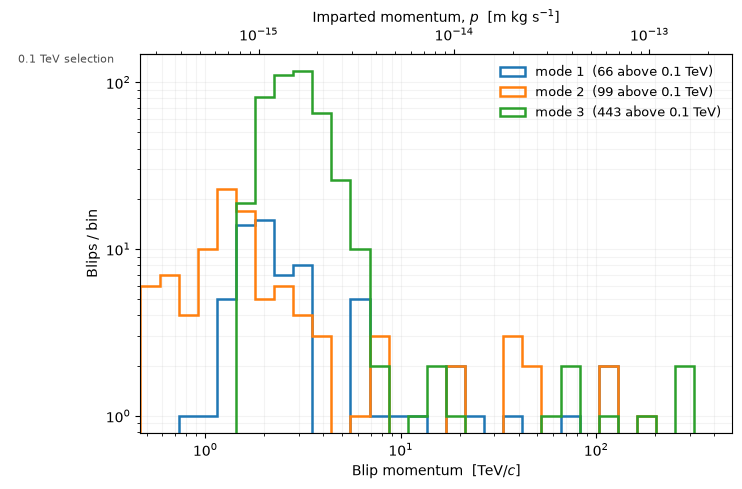

In [5]:
all_p = np.concatenate([ALL_MOMENTA[n] for n in MODES]) / 1e12  # TeV
bins = np.logspace(np.log10(all_p.min()), np.log10(all_p.max()), 32)

fig, ax = plt.subplots(figsize=(7.5, 5))
for n in MODES:
    ax.hist(ALL_MOMENTA[n] / 1e12, bins=bins, histtype="step", lw=1.8,
            color=COLORS[n],
            label=f"mode {n}  ({MOMENTA[n].size} above {Q_THRESH_TEV:g} TeV)")
ax.axvspan(bins[0], Q_THRESH_TEV, color="0.85", zorder=0)
ax.axvline(Q_THRESH_TEV, color="0.4", lw=1.0, ls="--", zorder=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(bins[0], bins[-1])
ax.set_xlabel(r"Blip momentum  [TeV/$c$]")
ax.set_ylabel("Blips / bin")
ax.grid(True, which="both", alpha=0.15)
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.text(Q_THRESH_TEV, ax.get_ylim()[1], f"  {Q_THRESH_TEV:g} TeV selection",
        ha="left", va="top", fontsize=8, color="0.3")
sec = ax.secondary_xaxis("top",
                         functions=(lambda t: t / TEV_PER_SI,
                                    lambda s: s * TEV_PER_SI))
sec.set_xlabel(r"Imparted momentum, $p$  [m kg s$^{-1}$]")
fig.tight_layout()
save_figure(fig, "00_blip_momentum_spectrum")
plt.show()

## Raw transient list (eV), per mode — candidates above 0.1 TeV

In [6]:
# compact view in TeV (full-precision eV lists live in data_mode{n}.txt)
for n in MODES:
    p_tev = MOMENTA[n] / 1e12
    print(f"# mode {n} \u2014 {p_tev.size} transient momenta [TeV/$c$]")
    print(np.array2string(p_tev, precision=2, separator=", ",
                          max_line_width=100, threshold=10_000))
    print()

# mode 1 — 66 transient momenta [TeV/$c$]
[  0.86,   0.95,   1.25,   1.31,   1.34,   1.35,   1.38,   1.44,   1.46,   1.48,   1.49,   1.52,
   1.54,   1.62,   1.63,   1.66,   1.66,   1.68,   1.73,   1.73,   1.76,   1.8 ,   1.81,   1.84,
   1.87,   2.01,   2.02,   2.02,   2.03,   2.04,   2.06,   2.09,   2.14,   2.15,   2.22,   2.25,
   2.37,   2.47,   2.51,   2.53,   2.58,   2.61,   2.72,   2.84,   2.86,   2.97,   2.99,   3.24,
   3.25,   3.34,   3.51,   5.71,   6.75,   6.76,   6.91,   6.91,   6.98,   9.48,  12.79,  18.56,
  18.62,  25.15,  38.61,  78.39, 113.31, 126.52]

# mode 2 — 99 transient momenta [TeV/$c$]
[  0.47,   0.48,   0.51,   0.54,   0.55,   0.57,   0.59,   0.59,   0.61,   0.67,   0.68,   0.68,
   0.7 ,   0.78,   0.79,   0.84,   0.9 ,   0.92,   0.93,   0.95,   1.02,   1.02,   1.09,   1.11,
   1.13,   1.13,   1.14,   1.15,   1.15,   1.18,   1.19,   1.19,   1.22,   1.25,   1.28,   1.29,
   1.31,   1.33,   1.34,   1.36,   1.36,   1.37,   1.37,   1.37,   1.37,   1.37,   1.39,  

## Per-mode candidate files

Each mode's candidates are written to `data_mode{n}.txt` (impulses in eV, one
per line, above the 0.1 TeV selection) — the per-mode analysis inputs the limit
scans read via `scan_grid.py --mode n --data data_mode{n}.txt`.

In [7]:
HEADER = (
    "# Observed impulse candidates for the POLONAISE UHDM search.\n"
    "# One impulse per line, in eV (momentum transfer q reconstructed\n"
    "# from the sensor ringdown); 1 GeV = 1e9 eV.\n"
    "# This file is the analysis input: edit it and rerun the notebooks.\n"
    "# mode {mode}: {count} candidates above {sel:g} TeV, {exp_h:.1f} h exposure.\n"
)
for n in MODES:
    p = MOMENTA[n]
    body = "".join(f"{v:.18e}\n" for v in p)
    text = HEADER.format(mode=n, count=p.size, sel=Q_THRESH_TEV,
                         exp_h=exposure_s / 3600) + body
    Path(f"data_mode{n}.txt").write_text(text)
    print(f"wrote data_mode{n}.txt  ({p.size} candidates)")

# show data_mode1.txt verbatim as an example
print()
print(Path('data_mode1.txt').read_text()[:600], '...')

wrote data_mode1.txt  (66 candidates)
wrote data_mode2.txt  (99 candidates)
wrote data_mode3.txt  (443 candidates)

# Observed impulse candidates for the POLONAISE UHDM search.
# One impulse per line, in eV (momentum transfer q reconstructed
# from the sensor ringdown); 1 GeV = 1e9 eV.
# This file is the analysis input: edit it and rerun the notebooks.
# mode 1: 66 candidates above 0.1 TeV, 469.7 h exposure.
8.609517122250187988e+11
9.476411505842362061e+11
1.245787463828386719e+12
1.305025962039022217e+12
1.339061851768527588e+12
1.348174522977445068e+12
1.377262107878865479e+12
1.443137775690741699e+12
1.461040963780538574e+12
1.478864512396489258e+12
1.486277269469930664e+12
1.520664613481074463e+12
1.54 ...
